In [21]:
import random
import time
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as sts

In [22]:
def can_R2_win(graph, weights, B):
    n = len(weights)
    memo = {}

    def dfs(selected_mask, R2_score, R2_turn):
        key = (selected_mask, R2_score, R2_turn)
        if key in memo:
            return memo[key]

        available = []
        for v in range(n):
            if (selected_mask >> v) & 1 == 0 and all((selected_mask >> u) & 1 == 0 for u in graph[v]):
                available.append(v)

        if not available:
            memo[key] = R2_score >= B
            return memo[key]

        if R2_turn:
            for v in available:
                new_mask = selected_mask | (1 << v)
                if dfs(new_mask, R2_score + weights[v], not R2_turn):
                    memo[key] = True
                    return True
            memo[key] = False
            return False
        else:
            for v in available:
                new_mask = selected_mask | (1 << v)
                if not dfs(new_mask, R2_score, not R2_turn):
                    memo[key] = False
                    return False
            memo[key] = True
            return True

    return dfs(0, 0, True)

In [23]:
def generate_random_graph(n, edge_prob=0.3, min_weight=1, max_weight=10, seed=None):
    if seed is not None:
        random.seed(seed)
    
    graph = [[] for _ in range(n)]
    for i in range(n):
        for j in range(i+1, n):
            if random.random() < edge_prob:
                graph[i].append(j)
                graph[j].append(i)
    
    weights = [random.randint(min_weight, max_weight) for _ in range(n)]
    return graph, weights

In [24]:
def measure_algorithm_time(algorithm, input_generator, n, n_trials=20, to_ms=False, **kwargs):
    trial_times = []
    for _ in range(n_trials):
        data = input_generator(n)
        start = time.perf_counter()
        algorithm(*data, **kwargs)
        end = time.perf_counter()
        elapsed = (end - start) * 1000 if to_ms else (end - start)
        trial_times.append(elapsed)
    trial_times = np.array(trial_times)
    mean_t = trial_times.mean()
    std_t = trial_times.std()
    return trial_times, mean_t, std_t

In [25]:
sizes = [i for i in range (5, 50, 5)]  
n_trials_graph = 3  
n_trials_hist = 100  
B_factor = 2 

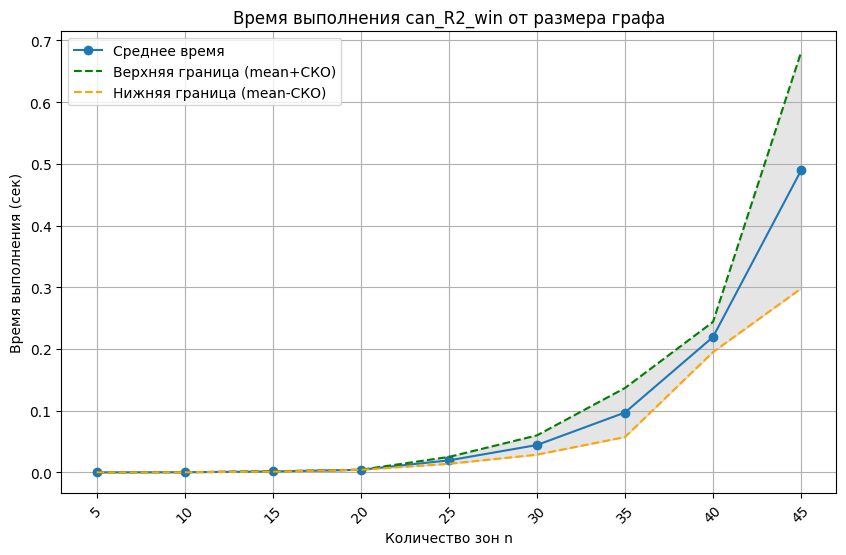

In [26]:
mean_times = []
std_times = []
q25_times = []
q75_times = []

for n in sizes:
    def input_gen(n):
        graph, weights = generate_random_graph(n, edge_prob=0.3, min_weight=1, max_weight=10)
        B = sum(weights) // B_factor
        return graph, weights, B
    
    times, mean_t, std_t = measure_algorithm_time(can_R2_win, input_gen, n, n_trials=n_trials_graph)
    mean_times.append(mean_t)
    std_times.append(std_t)
    q25_times.append(np.percentile(times, 25))
    q75_times.append(np.percentile(times, 75))

mean_times = np.array(mean_times)
std_times = np.array(std_times)
upper = mean_times + std_times
lower = mean_times - std_times

plt.figure(figsize=(10,6))
plt.plot(sizes, mean_times, 'o-', label='Среднее время')
plt.plot(sizes, upper, '--', color='green', label='Верхняя граница (mean+СКО)')
plt.plot(sizes, lower, '--', color='orange', label='Нижняя граница (mean-СКО)')
plt.fill_between(sizes, lower, upper, color='gray', alpha=0.2)
plt.xlabel('Количество зон n')
plt.xticks(sizes, [f"{x:,}" for x in sizes], rotation=45) 
plt.ylabel('Время выполнения (сек)')
plt.title('Время выполнения can_R2_win от размера графа')
plt.grid(True)
plt.legend()
plt.show()

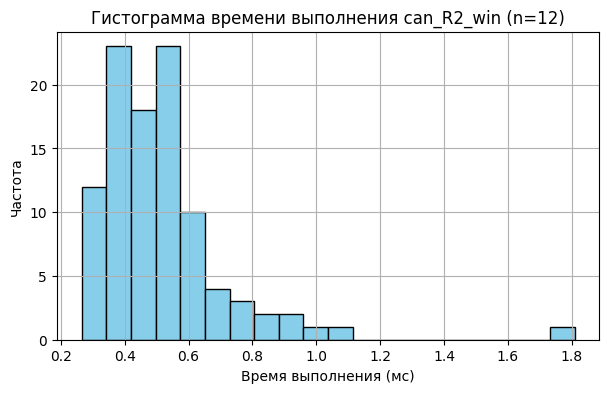

Среднее время: 0.516086 мс, Стандартное отклонение: 0.205178 мс


In [27]:
n_hist = 12

def input_gen_hist(n):
    graph, weights = generate_random_graph(n, edge_prob=0.3, min_weight=1, max_weight=10)
    B = sum(weights) // B_factor
    return graph, weights, B

times, mean_t, std_t = measure_algorithm_time(can_R2_win, input_gen_hist, n_hist, n_trials=n_trials_hist, to_ms=True)

plt.figure(figsize=(7,4))
plt.hist(times, bins=20, color='skyblue', edgecolor='black')
plt.xlabel('Время выполнения (мс)')
plt.ylabel('Частота')
plt.title(f'Гистограмма времени выполнения can_R2_win (n={n_hist})')
plt.grid(True)
plt.show()

print(f"Среднее время: {mean_t:.6f} мс, Стандартное отклонение: {std_t:.6f} мс")

In [28]:
# Проверка гипотезы нормальности (Шапиро-Уилка)
stat, p_value = sts.shapiro(times)
print(f"Shapiro-Wilk test: статистика={stat:.4f}, p-value={p_value:.4f}")
if p_value > 0.05:
    print("Гипотеза о нормальном распределении не отвергается (данные примерно нормальны)")
else:
    print("Гипотеза о нормальном распределении отвергается (данные не нормальны)")

Shapiro-Wilk test: статистика=0.7537, p-value=0.0000
Гипотеза о нормальном распределении отвергается (данные не нормальны)


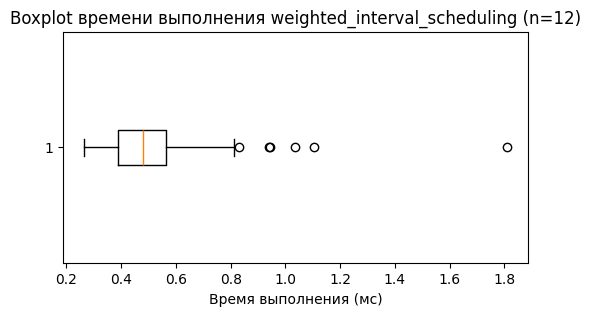

In [29]:
plt.figure(figsize=(6,3))
plt.boxplot(times, vert=False)
plt.xlabel('Время выполнения (мс)')
plt.title(f'Boxplot времени выполнения weighted_interval_scheduling (n={n_hist})')
plt.show()

In [30]:
median_t = np.median(times)
q25, q75 = np.percentile(times, [25, 75])
print(f"Медиана времени: {median_t:.2f} мс")
print(f"25% и 75% квантиль: {q25:.2f} мс, {q75:.2f} мс")
print(f"Минимум и максимум: {times.min():.2f} мс, {times.max():.2f} мс")

Медиана времени: 0.48 мс
25% и 75% квантиль: 0.39 мс, 0.56 мс
Минимум и максимум: 0.26 мс, 1.81 мс
